#📊Balanced Scorecard y Segmentación Estratégica (Control de Gestión).

###Enfoque: Centros de Responsabilidad y Cuadro de Mando Integral.

###Autor: Jorge Nieto.-

In [ ]:
# ==============================================================================
# FASE 1: INSTALACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
# Instalamos el driver nativo de Postgres adaptado para entornos Python
!pip install psycopg2-binary -q

import os
import sqlite3
import numpy as np
import pandas as pd
import psycopg2
from psycopg2 import extras
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata, files

# Configuración de estilos visuales para los gráficos del Portfolio
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 39.5 MB/s eta 0:00:00


In [ ]:
# ==============================================================================
# FASE 2: CONEXIÓN SEGURA A NEON SQL (POSTGRESQL) UTILIZANDO SECRETS
# ==============================================================================
# IMPORTANTE: Debes ir al menú lateral de Colab 🔑 (Secrets) y añadir 'NEON_DB_URL'
try:
    DATABASE_URL = userdata.get('NEON_DB_URL')
    print("✅ Enlace secreto 'NEON_DB_URL' recuperado exitosamente.")
except Exception as e:
    print("❌ Error: Asegúrate de configurar la clave 'NEON_DB_URL' en tus Secrets de Colab.", e)

def get_neon_connection():
    """Establece y retorna la conexión activa hacia el clúster de Neon."""
    return psycopg2.connect(DATABASE_URL)

✅ Enlace secreto 'NEON_DB_URL' recuperado exitosamente.


In [ ]:
# ==============================================================================
# FASE 3: SIMULACIÓN DE CENTROS DE RESPONSABILIDAD (SUCURSALES ARGENTINA)
# ==============================================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(56)
n_sucursales = 80

# Simulación de indicadores financieros y de operación de control directivo
data_sucursales = {
    "sucursal_id": [f"SUC-{i:03d}" for i in range(1, n_sucursales + 1)],
    "region": np.random.choice(["Centro-CBA", "NOA", "Cuyo", "Pampeana"], n_sucursales),
    "activos_operativos_ars": np.random.uniform(5000000, 25000000, n_sucursales),
    "utilidad_neta_operativa": np.random.uniform(800000, 6000000, n_sucursales),
    "porcentaje_entregas_a_tiempo": np.random.uniform(75, 99, n_sucursales) # Perspectiva Procesos Internos
}

df_centros = pd.DataFrame(data_sucursales)

# Fórmulas obligatorias de Control de Gestión
# Rendimiento sobre la Inversión (RSI) = Utilidad / Activos
df_centros["rsi"] = df_centros["utilidad_neta_operativa"] / df_centros["activos_operativos_ars"]
# Tasa de costo de capital asignada = 15%
tasa_capital = 0.15
df_centros["ingreso_residual"] = df_centros["utilidad_neta_operativa"] - (tasa_capital * df_centros["activos_operativos_ars"])

In [ ]:
# ==============================================================================
# FASE 4: MACHINE LEARNING NO SUPERVISADO (CLUSTERING K-MEANS)
# ==============================================================================
# Agrupamos las sucursales por desempeño financiero y de servicio al cliente
features_clustering = ["rsi", "ingreso_residual", "porcentaje_entregas_a_tiempo"]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_centros[features_clustering])

# Buscamos separar en 3 niveles de gestión: Alto Desempeño, Estable, Requiere Auditoría
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_centros["categoria_gestion_cluster"] = kmeans.fit_predict(scaled_features)

In [ ]:
# ==============================================================================
# FASE 5: INGESTA IDEMPOTENTE EN EL ESQUEMA DE SCORECARD
# ==============================================================================
conn = get_neon_connection()
cursor = conn.cursor()

cursor.execute("""
    DROP TABLE IF EXISTS proyecto3_scorecard.cuadro_mando_centros;
    CREATE TABLE proyecto3_scorecard.cuadro_mando_centros (
        sucursal_id VARCHAR(20) PRIMARY KEY,
        region VARCHAR(30),
        activos_operativos_ars FLOAT,
        utilidad_neta_operativa FLOAT,
        porcentaje_entregas_a_tiempo FLOAT,
        rsi FLOAT,
        ingreso_residual FLOAT,
        categoria_gestion_cluster INT
    );
""")
conn.commit()

query_insert_centros = "INSERT INTO proyecto3_scorecard.cuadro_mando_centros VALUES (%s,%s,%s,%s,%s,%s,%s,%s)"
extras.execute_batch(cursor, query_insert_centros, df_centros.values.tolist())
conn.commit()
cursor.close()
conn.close()
print("🚀 ¡Cuadro de Mando Integral subido con éxito a 'proyecto3_scorecard'!")

🚀 ¡Cuadro de Mando Integral subido con éxito a 'proyecto3_scorecard'!


In [ ]:
# ==============================================================================
# FASE 6: CREACIÓN DE VISTA ANALÍTICA PARA POWER BI (OPCIONAL EN COLAB)
# ==============================================================================
conn = get_neon_connection()
cursor = conn.cursor()

cursor.execute("""
CREATE OR REPLACE VIEW proyecto3_scorecard.v_bi_cuadro_mando AS
SELECT
    sucursal_id AS "Código Sucursal",
    region AS "Región Geográfica",
    ROUND(activos_operativos_ars::numeric, 2) AS "Activos Operativos ($)",
    ROUND(utilidad_neta_operativa::numeric, 2) AS "Utilidad Neta Operativa ($)",
    ROUND((porcentaje_entregas_a_tiempo)::numeric, 2) AS "% Entregas a Tiempo (Procesos)",
    ROUND((rsi * 100)::numeric, 2) AS "% Rendimiento sobre Inversión (RSI)",
    ROUND(ingreso_residual::numeric, 2) AS "Ingreso Residual ($)",
    CASE categoria_gestion_cluster
        WHEN 0 THEN 'Desempeño Crítico (Requiere Auditoría)'
        WHEN 1 THEN 'Desempeño Estándar (Estable)'
        WHEN 2 THEN 'Desempeño Sobresaliente (Unidad Estrella)'
        ELSE 'No Clasificado'
    END AS "Segmento de Gestión (K-Means)"
FROM proyecto3_scorecard.cuadro_mando_centros;
""")
conn.commit()
cursor.close()
conn.close()
print("✅ Vista 'v_bi_cuadro_mando' generada en Neon desde Colab.")

✅ Vista 'v_bi_cuadro_mando' generada en Neon desde Colab.


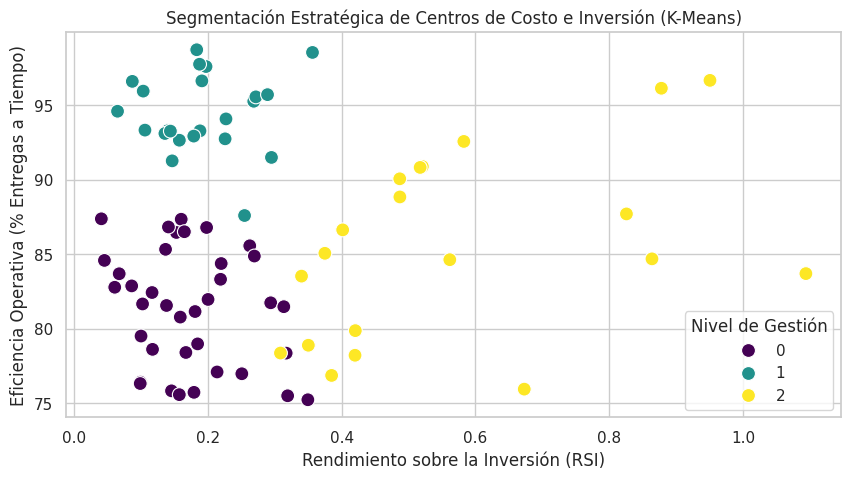

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==============================================================================
# FASE 7: AUDITORÍA VISUAL Y DESCARGA LOCAL DE TABLAS
# ==============================================================================
# Visualización del mapa estratégico de clusters para el cuadro directivo
sns.scatterplot(
    data=df_centros,
    x="rsi",
    y="porcentaje_entregas_a_tiempo",
    hue="categoria_gestion_cluster",
    palette="viridis",
    s=100
)
plt.title("Segmentación Estratégica de Centros de Costo e Inversión (K-Means)")
plt.xlabel("Rendimiento sobre la Inversión (RSI)")
plt.ylabel("Eficiencia Operativa (% Entregas a Tiempo)")
plt.legend(title="Nivel de Gestión")
plt.show()

# Descarga local
df_centros.to_csv("cuadro_mando_gestion.csv", index=False)
files.download("cuadro_mando_gestion.csv")